# INPUT DATASET

In [20]:
# Data handling
import pandas as pd
import numpy as np
import json
import re

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# GIS / peta
import geopandas as gpd
import folium

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score, confusion_matrix

# Menyimpan Model
import joblib

# Elbow method helper
from kneed import KneeLocator

In [21]:
df = pd.read_csv("Dataset Fix Kemiskinan 2025.csv")

# EDA AWAL

In [22]:
# Mengidentifikasi
print("INFO DATASET:")
df.info()
print("\n5 DATASET TERATAS")
df.head()

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Kabupaten/Kota Se Jawa Timur            38 non-null     object 
 1   Garis Kemiskinan (Rupiah/Bulan/Kapita)  38 non-null     int64  
 2   Jumlah Penerima Bantuan Sosial          38 non-null     int64  
 3   UMK (Rupiah)                            38 non-null     int64  
 4   TPT (Persen)                            38 non-null     float64
 5   Indeks Kedalaman Kemiskinan (P1)        38 non-null     float64
 6   Indeks Keparahan Kemiskinan (P2)        38 non-null     float64
 7   Gini Rasio                              38 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 2.5+ KB

5 DATASET TERATAS


,Kabupaten/Kota Se Jawa Timur,Garis Kemiskinan (Rupiah/Bulan/Kapita),Jumlah Penerima Bantuan Sosial,UMK (Rupiah),TPT (Persen),Indeks Kedalaman Kemiskinan (P1),Indeks Keparahan Kemiskinan (P2),Gini Rasio
0,Kabupaten Pacitan,386174,469,2514892,1.40,1.77,0.36,0.365
1,Kabupaten Ponorogo,428183,0,2549876,3.85,1.22,0.26,0.329
2,Kabupaten Trenggalek,450334,0,2530313,3.86,1.09,0.20,0.359
3,Kabupaten Tulungagung,463364,0,2628190,4.03,0.42,0.04,0.291
4,Kabupaten Blitar,417158,0,2567744,4.49,1.21,0.27,0.351


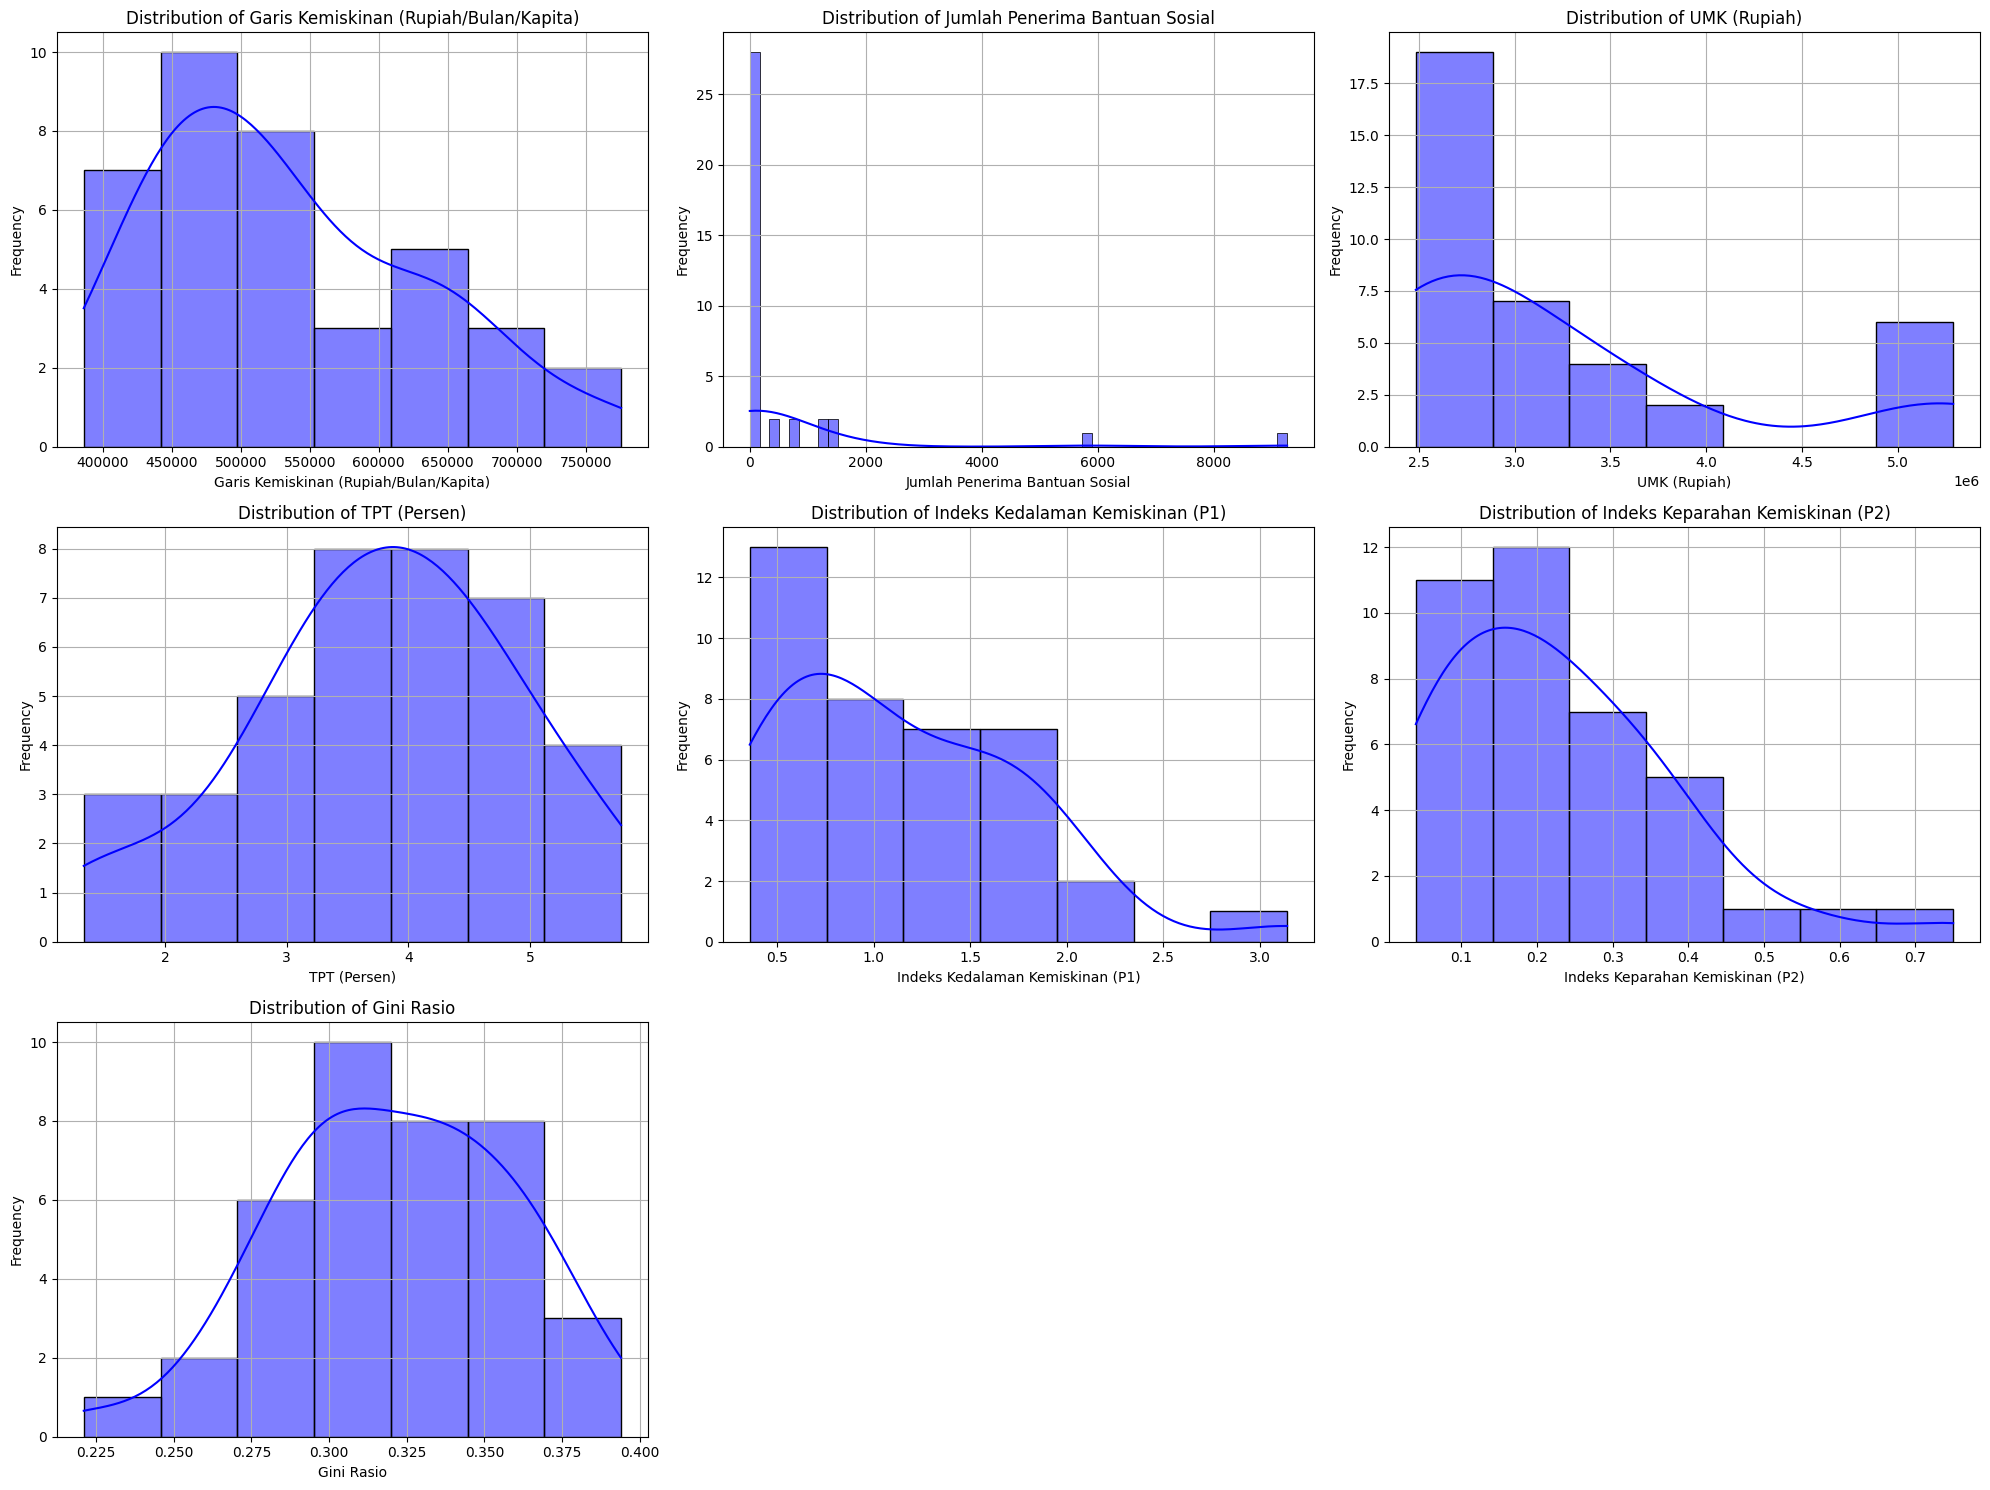

In [23]:
# Membuat histogram untuk semua kolom numerik
numerical_df = df.select_dtypes(include=[np.number])
num_cols = len(numerical_df.columns)

if num_cols > 0:
    n_rows = (num_cols + 2) // 3 # Bagi jadi 3 kolom 1 baris
    plt.figure(figsize=(20, 5 * n_rows))

    for i, column in enumerate(numerical_df.columns):
        plt.subplot(n_rows, 3, i + 1)
        # Menggunakan histplot
        sns.histplot(numerical_df[column], color='blue', kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom numerik")

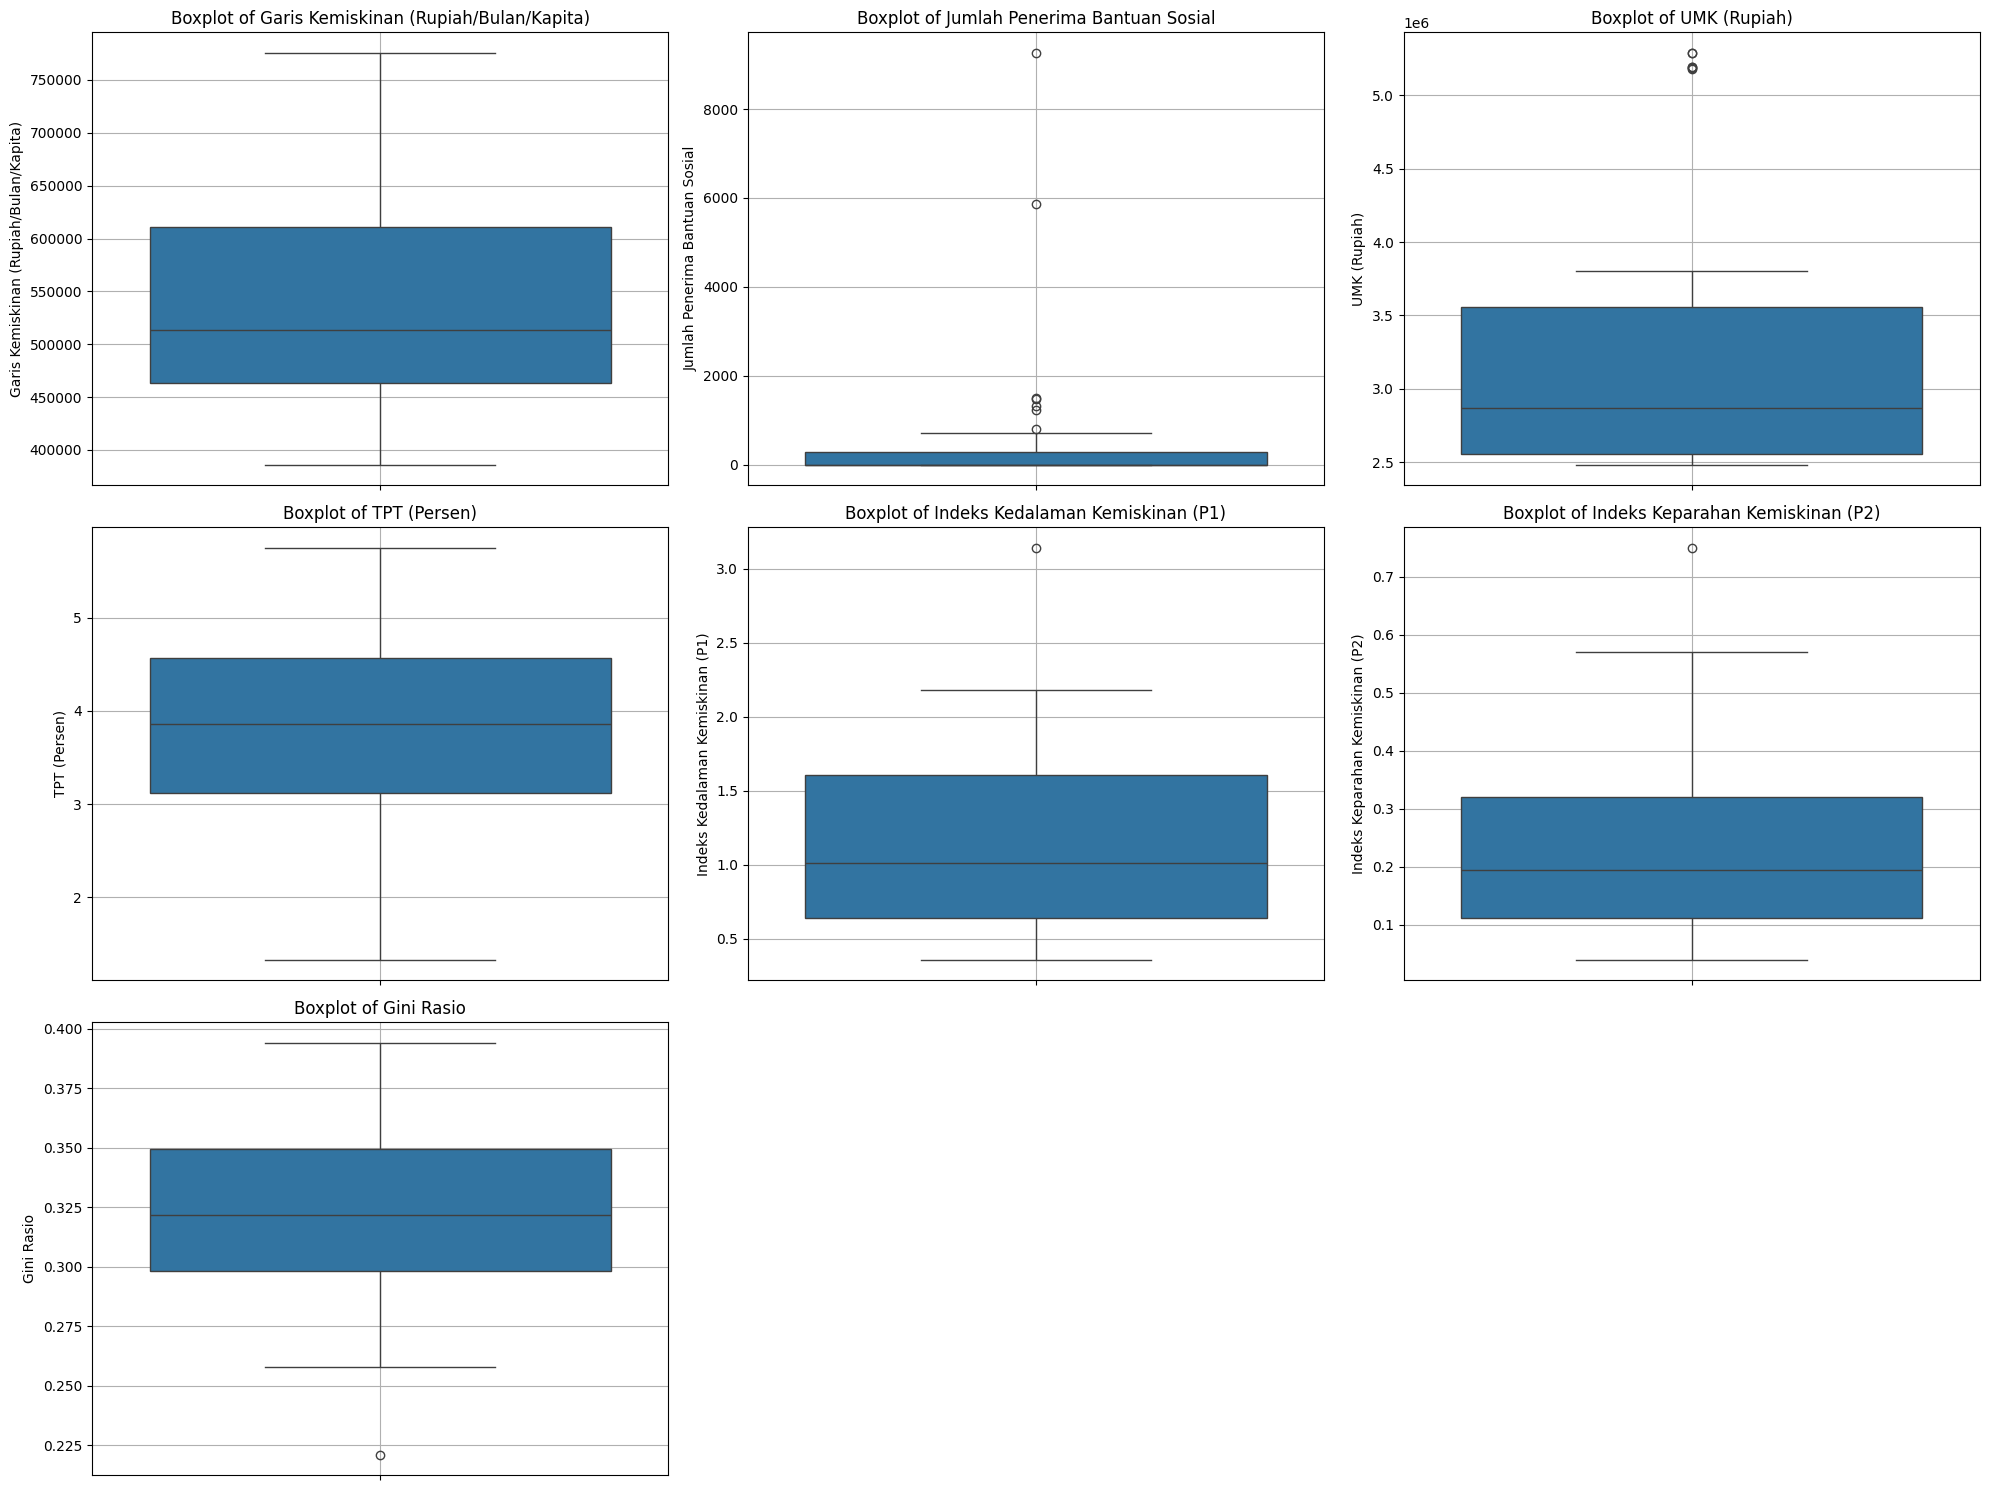

In [24]:
# Membuat boxplot untuk semua kolom numerik
numerical_df = df.select_dtypes(include=[np.number])
num_cols = len(numerical_df.columns)

if num_cols > 0:
    n_rows = (num_cols + 2) // 3 # Bagi jadi 3 kolom 1 baris
    plt.figure(figsize=(20, 5 * n_rows))

    for i, column in enumerate(numerical_df.columns):
        plt.subplot(n_rows, 3, i + 1)
        sns.boxplot(y=numerical_df[column])
        plt.title(f'Boxplot of {column}')
        plt.ylabel(column)
        plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
     print("Tidak ada kolom numerik")

# PREPOCESSING AWAL

In [25]:
df.describe()

,Garis Kemiskinan (Rupiah/Bulan/Kapita),Jumlah Penerima Bantuan Sosial,UMK (Rupiah),TPT (Persen),Indeks Kedalaman Kemiskinan (P1),Indeks Keparahan Kemiskinan (P2),Gini Rasio
count,38.000000,38.000000,3.800000e+01,38.000000,38.000000,38.000000,38.000000
mean,533304.210526,605.263158,3.249375e+06,3.779737,1.137368,0.227368,0.320579
std,96886.338715,1766.077493,9.488189e+05,1.112758,0.639826,0.157989,0.037776
min,386174.000000,0.000000,2.483962e+06,1.330000,0.360000,0.040000,0.221000
25%,463738.250000,0.000000,2.553338e+06,3.115000,0.642500,0.112500,0.298250
50%,513094.500000,0.000000,2.865976e+06,3.855000,1.015000,0.195000,0.321500
75%,610511.250000,285.750000,3.560688e+06,4.565000,1.607500,0.320000,0.349250
max,775597.000000,9262.000000,5.288796e+06,5.750000,3.140000,0.750000,0.394000


## Cek Data Duplikat

In [26]:
# Cek duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

# Hapus Duplikat
# df.drop_duplicates(inplace=True)
# print(f"Jumlah baris setelah menghapus duplikat : {len(df)}")

Jumlah data duplikat: 0


## Cek Missing Value

In [27]:
# Mengecek jumlah data kosong di setiap kolom
print(df.isnull().sum())

Kabupaten/Kota Se Jawa Timur              0
Garis Kemiskinan (Rupiah/Bulan/Kapita)    0
Jumlah Penerima Bantuan Sosial            0
UMK (Rupiah)                              0
TPT (Persen)                              0
Indeks Kedalaman Kemiskinan (P1)          0
Indeks Keparahan Kemiskinan (P2)          0
Gini Rasio                                0
dtype: int64


## Cek Outlier

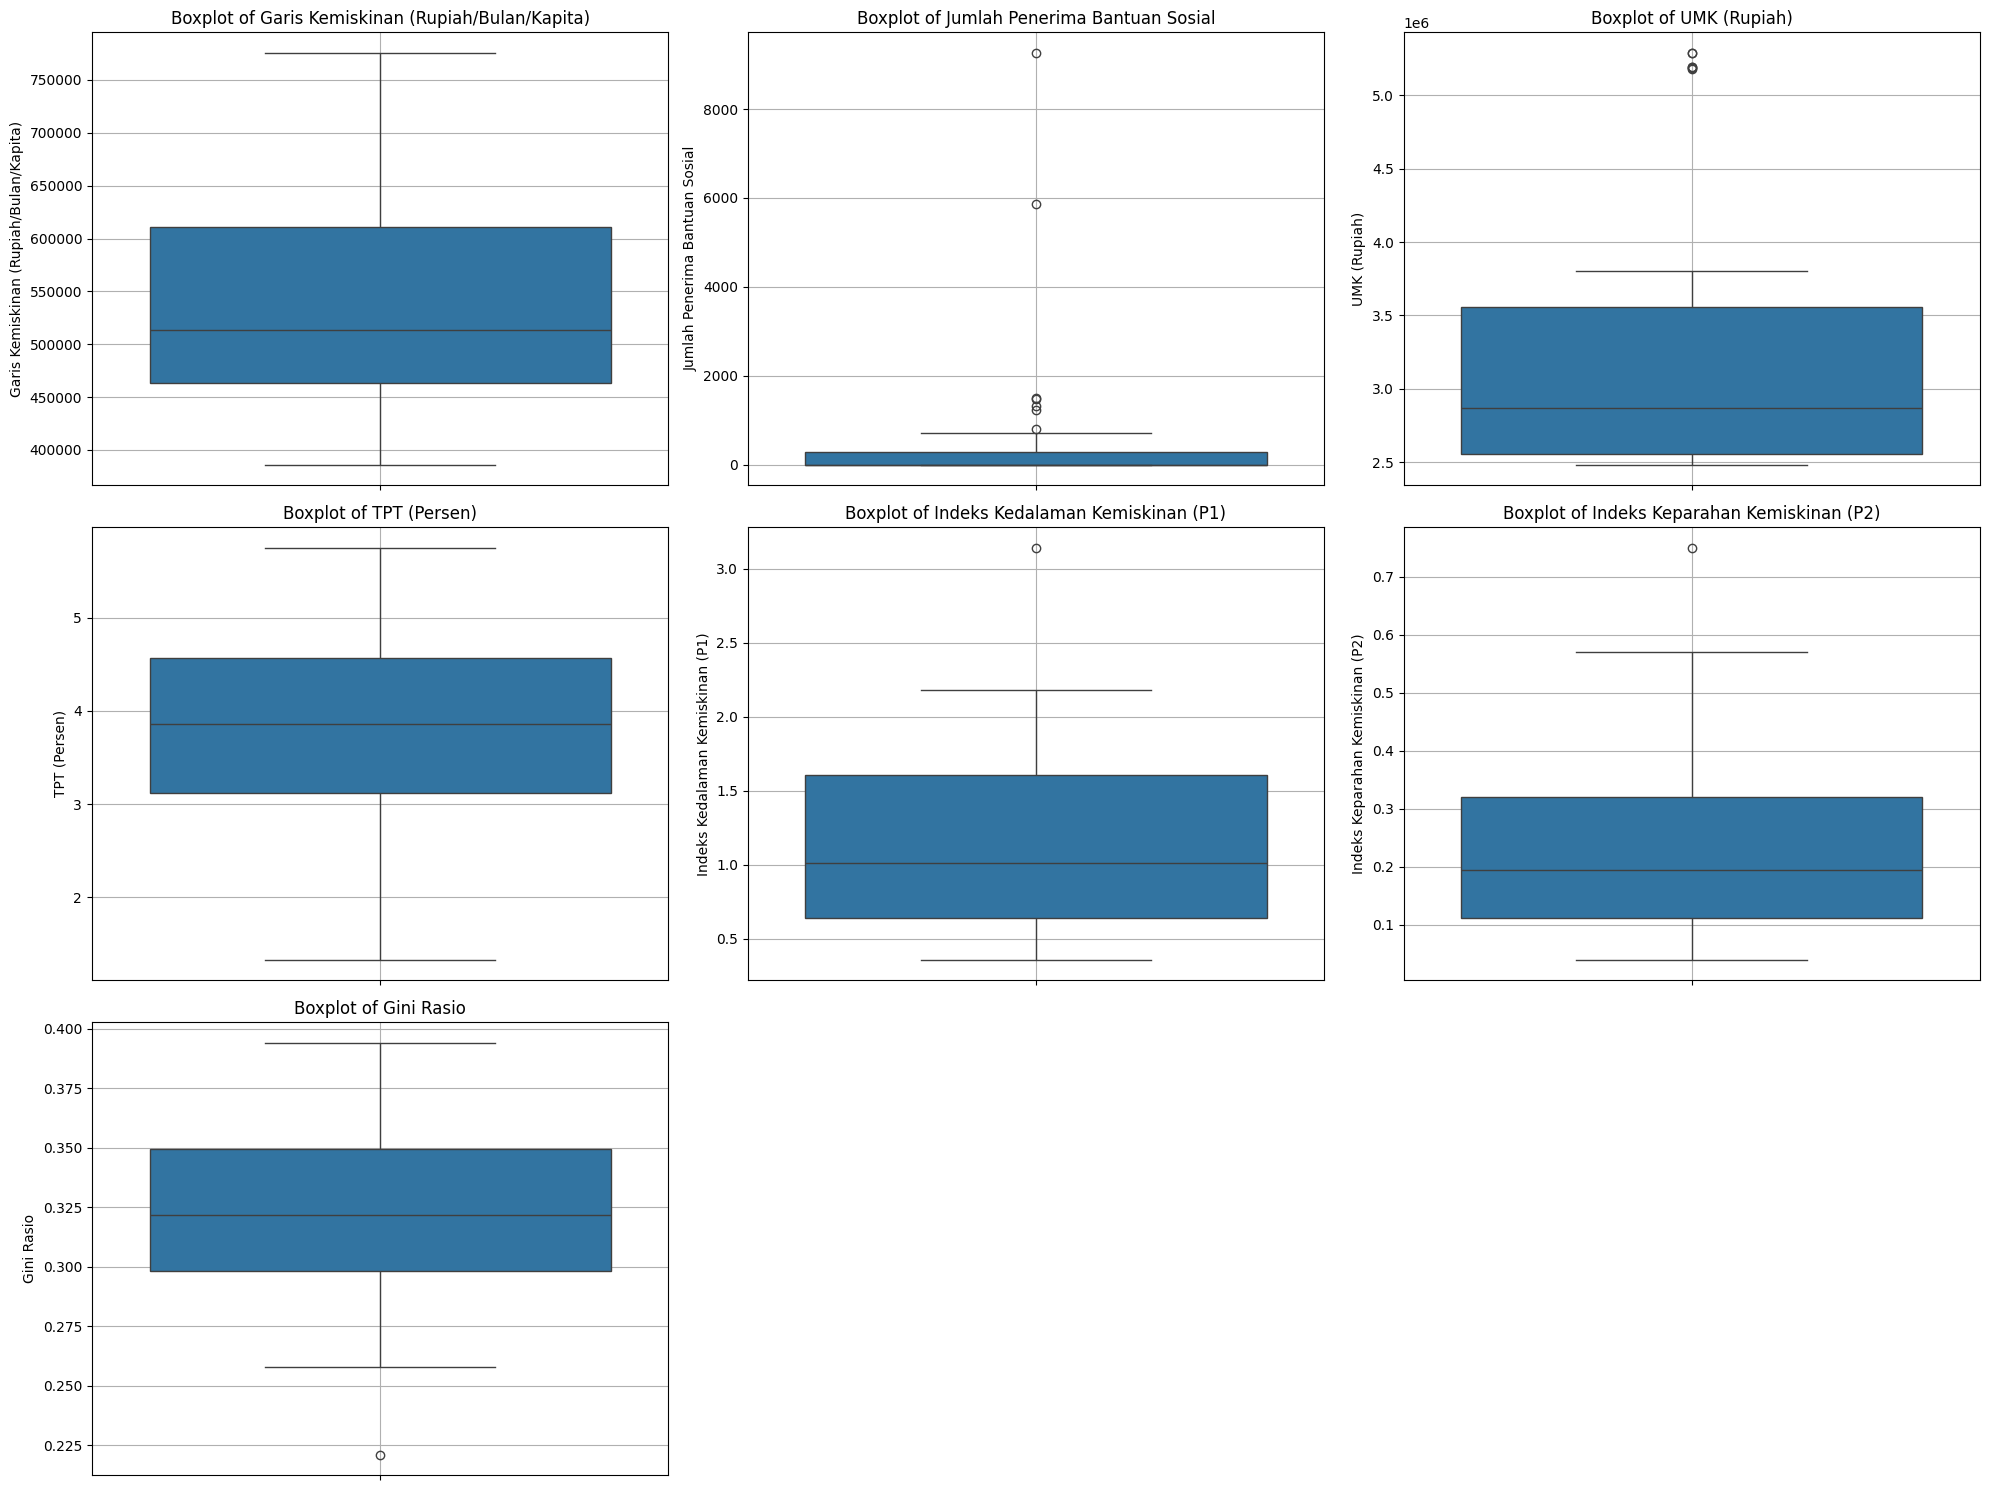

In [28]:
# Membuat boxplot untuk semua kolom numerik
numerical_df = df.select_dtypes(include=[np.number])
num_cols = len(numerical_df.columns)

if num_cols > 0:
    n_rows = (num_cols + 2) // 3
    plt.figure(figsize=(20, 5 * n_rows))

    for i, column in enumerate(numerical_df.columns):
        plt.subplot(n_rows, 3, i + 1) #
        sns.boxplot(y=numerical_df[column])
        plt.title(f'Boxplot of {column}')
        plt.ylabel(column)
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## Cek Inkonsistensi

In [29]:
# Cek inkonsistensi
print("INFO DATASET:")
df.info()

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Kabupaten/Kota Se Jawa Timur            38 non-null     object 
 1   Garis Kemiskinan (Rupiah/Bulan/Kapita)  38 non-null     int64  
 2   Jumlah Penerima Bantuan Sosial          38 non-null     int64  
 3   UMK (Rupiah)                            38 non-null     int64  
 4   TPT (Persen)                            38 non-null     float64
 5   Indeks Kedalaman Kemiskinan (P1)        38 non-null     float64
 6   Indeks Keparahan Kemiskinan (P2)        38 non-null     float64
 7   Gini Rasio                              38 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 2.5+ KB


In [30]:
# Cek inkonsistensi pada kolom kategorikal
object_columns = df.select_dtypes(include=['object']).columns

if len(object_columns) == 0:
    print("Tidak ada kolom bertipe 'object' untuk diperiksa inkonsistensi.")
else:
    print("Memeriksa inkonsistensi pada kolom bertipe 'object':")
    for col in object_columns:
        print(f"\n--- Kolom: {col} ---")
        print(df[col].value_counts())
        print("\nUnique values:")
        print(df[col].unique())


Memeriksa inkonsistensi pada kolom bertipe 'object':

--- Kolom: Kabupaten/Kota Se Jawa Timur ---
Kabupaten/Kota Se Jawa Timur
Kabupaten Pacitan        1
Kabupaten Ponorogo       1
Kabupaten Trenggalek     1
Kabupaten Tulungagung    1
Kabupaten Blitar         1
Kabupaten Kediri         1
Kabupaten Malang         1
Kabupaten Lumajang       1
Kabupaten Jember         1
Kabupaten Banyuwangi     1
Kabupaten Bondowoso      1
Kabupaten Situbondo      1
Kabupaten Probolinggo    1
Kabupaten Pasuruan       1
Kabupaten Sidoarjo       1
Kabupaten Mojokerto      1
Kabupaten Jombang        1
Kabupaten Nganjuk        1
Kabupaten Madiun         1
Kabupaten Magetan        1
Kabupaten Ngawi          1
Kabupaten Bojonegoro     1
Kabupaten Tuban          1
Kabupaten Lamongan       1
Kabupaten Gresik         1
Kabupaten Bangkalan      1
Kabupaten Sampang        1
Kabupaten Pamekasan      1
Kabupaten Sumenep        1
Kota Kediri              1
Kota Blitar              1
Kota Malang              1
Kota Prob

# FEAUTURE ENGINEERING & MENAMBAHKAN FITUR

**Rasio Kesejahteraan :**
```
**UMK / GARIS KEMISKINAN**
```
Rasio kecil → UMK tidak jauh dari garis kemiskinan → masyarakat lebih rentan

Rasio besar → UMK jauh di atas garis kemiskinan → kondisi lebih aman

* < 1.5	Kelas Rentan
* 1.5 – 3.5	Menuju Kelas Menengah
* 3.5 - 17 Kelas Menengah
* 17 Kelas Atas

In [31]:
df["Rasio UMK & GK"] = df["UMK (Rupiah)"] / df["Garis Kemiskinan (Rupiah/Bulan/Kapita)"]
def kategori_rasio(x):
    if x < 1.5:
        return "Kelas Rentan"
    elif x < 3.5:
        return "Menuju Kelas Menengah"
    elif x < 17:
        return "Kelas Menengah"
    else:
        return "Kelas Atas"

df["Kategori Kesejahteraan"] = df["Rasio UMK & GK"].apply(kategori_rasio)

# Menampilkan hasil beberapa data
df[["UMK (Rupiah)",
    "Garis Kemiskinan (Rupiah/Bulan/Kapita)",
    "Rasio UMK & GK",
    "Kategori Kesejahteraan"]].head()

,UMK (Rupiah),Garis Kemiskinan (Rupiah/Bulan/Kapita),Rasio UMK & GK,Kategori Kesejahteraan
0,2514892,386174,6.512329,Kelas Menengah
1,2549876,428183,5.955108,Kelas Menengah
2,2530313,450334,5.618747,Kelas Menengah
3,2628190,463364,5.671977,Kelas Menengah
4,2567744,417158,6.155327,Kelas Menengah


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Kabupaten/Kota Se Jawa Timur            38 non-null     object 
 1   Garis Kemiskinan (Rupiah/Bulan/Kapita)  38 non-null     int64  
 2   Jumlah Penerima Bantuan Sosial          38 non-null     int64  
 3   UMK (Rupiah)                            38 non-null     int64  
 4   TPT (Persen)                            38 non-null     float64
 5   Indeks Kedalaman Kemiskinan (P1)        38 non-null     float64
 6   Indeks Keparahan Kemiskinan (P2)        38 non-null     float64
 7   Gini Rasio                              38 non-null     float64
 8   Rasio UMK & GK                          38 non-null     float64
 9   Kategori Kesejahteraan                  38 non-null     object 
dtypes: float64(5), int64(3), object(2)
memory usage: 3.1+ KB


# NORMALISASI MIN-MAX

In [33]:
# Normalisasi Min Max
df_normalization = df.copy()

# Pilih kolom yang ingin dinormalisasi
cols = [
    "Garis Kemiskinan (Rupiah/Bulan/Kapita)",
    "UMK (Rupiah)",
    "TPT (Persen)",
    "Indeks Kedalaman Kemiskinan (P1)",
    "Indeks Keparahan Kemiskinan (P2)",
    "Gini Rasio",
    "Rasio UMK & GK"
]

print("=== Sebelum Normalisasi ===")
print(df_normalization[cols].head())

scaler = MinMaxScaler()
df_normalization[cols] = scaler.fit_transform(df_normalization[cols])

print("\n=== Sesudah Normalisasi ===")
print(df_normalization[cols].head())

=== Sebelum Normalisasi ===
   Garis Kemiskinan (Rupiah/Bulan/Kapita)  UMK (Rupiah)  TPT (Persen)  \
0                                  386174       2514892          1.40   
1                                  428183       2549876          3.85   
2                                  450334       2530313          3.86   
3                                  463364       2628190          4.03   
4                                  417158       2567744          4.49   

   Indeks Kedalaman Kemiskinan (P1)  Indeks Keparahan Kemiskinan (P2)  \
0                              1.77                              0.36   
1                              1.22                              0.26   
2                              1.09                              0.20   
3                              0.42                              0.04   
4                              1.21                              0.27   

   Gini Rasio  Rasio UMK & GK  
0       0.365        6.512329  
1       0.329        5.955108 

# EKSPLORASI VISUALISASI DATA

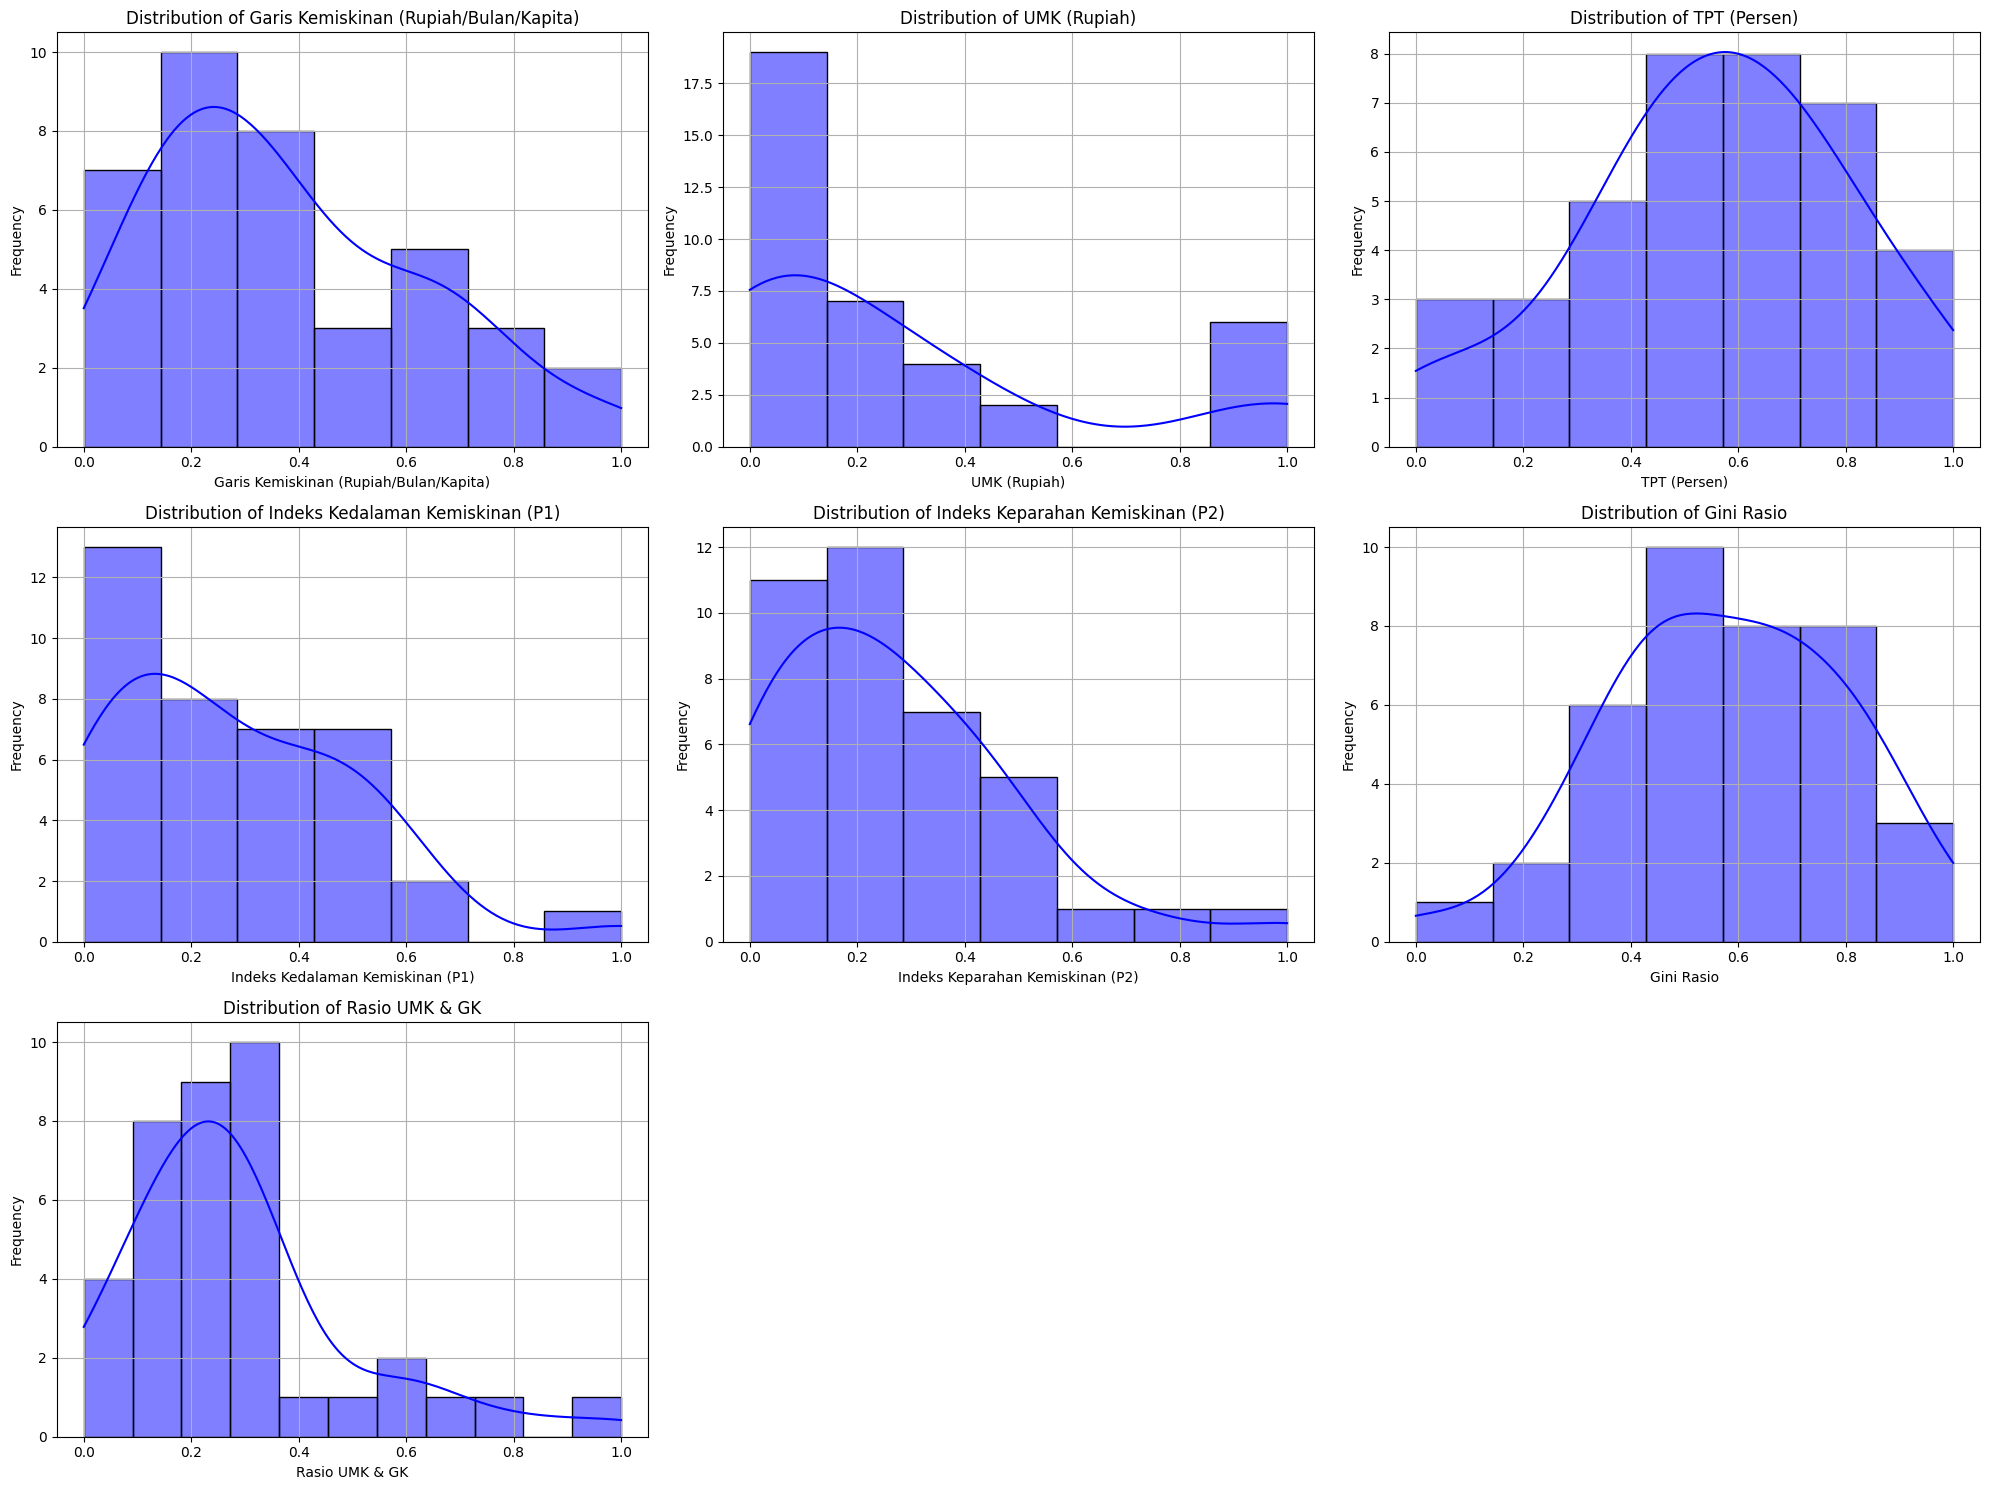

In [34]:
# Membuat histogram untuk semua kolom numerik
numerical_df = df_normalization[cols]
num_cols = len(numerical_df.columns)

if num_cols > 0:
    n_rows = (num_cols + 2) // 3 # Bagi jadi 3 kolom 1 baris
    plt.figure(figsize=(20, 5 * n_rows))

    for i, column in enumerate(numerical_df.columns):
        plt.subplot(n_rows, 3, i + 1)
        # Menggunakan histplot
        sns.histplot(numerical_df[column], color='blue', kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom numerik")

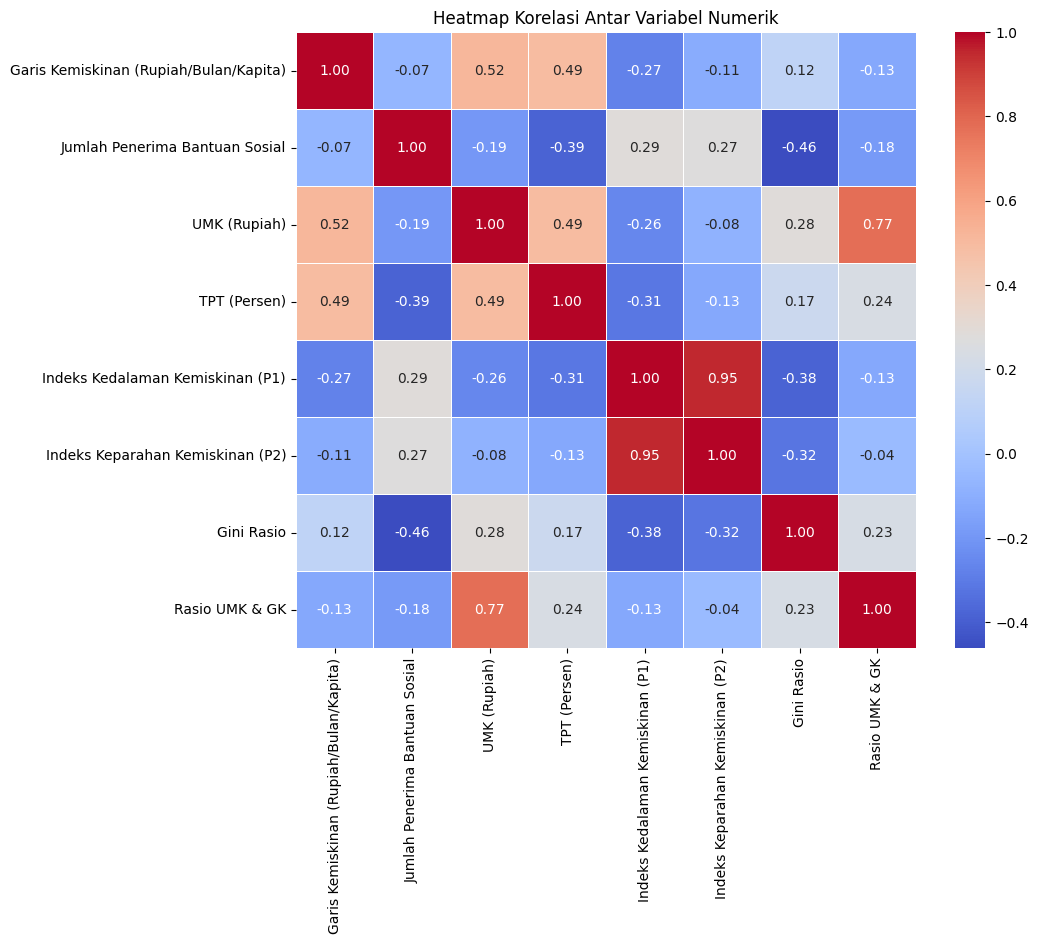

In [35]:
# Pilih hanya kolom numerik
numerical_df = df.select_dtypes(include=[np.number])

# Hitung matriks korelasi
correlation_matrix = numerical_df.corr()

# Buat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

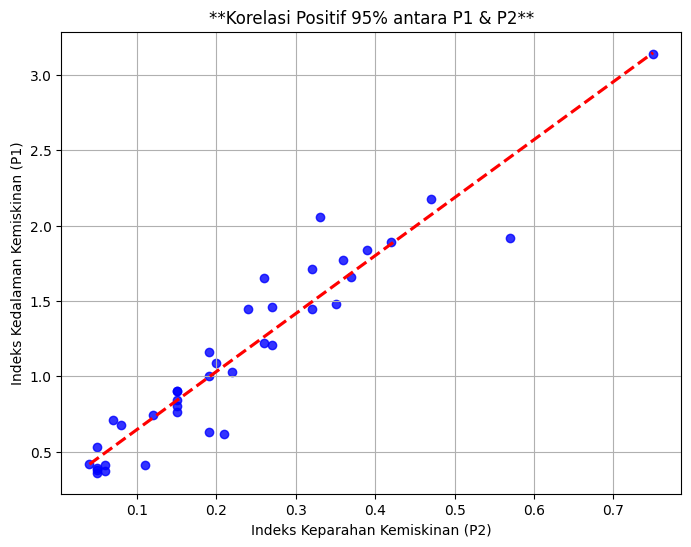

Koefisien Korelasi antara Indeks Keparahan Kemiskinan (P2) dan Indeks Kedalaman Kemiskinan (P1): 0.95


In [36]:
# Pilih dua variabel yang diminati
var1 = 'Indeks Keparahan Kemiskinan (P2)'
var2 = 'Indeks Kedalaman Kemiskinan (P1)'

# Buat scatter plot dengan garis regresi yang disesuaikan
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x=var1, y=var2, ci=None, scatter_kws={'color':'blue'}, line_kws={'color':'red', 'linestyle':'--'})
plt.title(f'**Korelasi Positif 95% antara P1 & P2**')
plt.xlabel(var1)
plt.ylabel(var2)
plt.grid(True)
plt.show()

# Hitung dan tampilkan koefisien korelasi
correlation = df[var1].corr(df[var2])
print(f"Koefisien Korelasi antara {var1} dan {var2}: {correlation:.2f}")

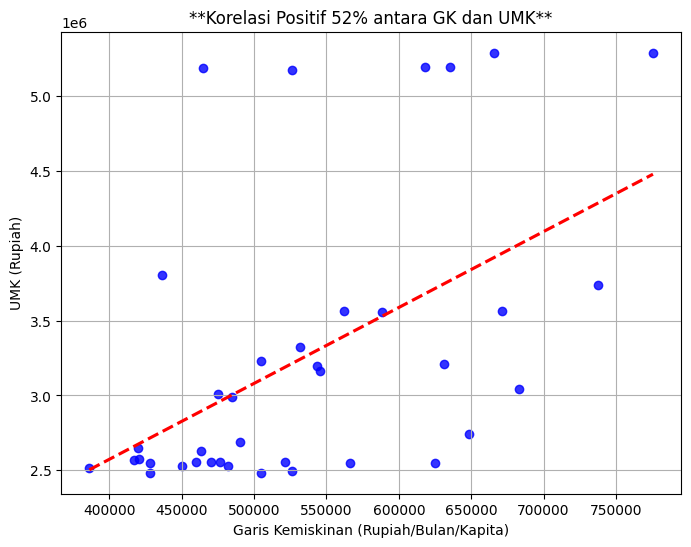

Koefisien Korelasi antara Garis Kemiskinan (Rupiah/Bulan/Kapita) dan UMK (Rupiah): 0.52


In [37]:
# Pilih dua variabel yang diminati
var1 = 'Garis Kemiskinan (Rupiah/Bulan/Kapita)'
var2 = 'UMK (Rupiah)'

# Buat scatter plot dengan garis regresi yang disesuaikan
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x=var1, y=var2, ci=None, scatter_kws={'color':'blue'}, line_kws={'color':'red', 'linestyle':'--'})
plt.title(f'**Korelasi Positif 52% antara GK dan UMK**')
plt.xlabel(var1)
plt.ylabel(var2)
plt.grid(True)
plt.show()

# Hitung dan tampilkan koefisien korelasi
correlation = df[var1].corr(df[var2])
print(f"Koefisien Korelasi antara {var1} dan {var2}: {correlation:.2f}")

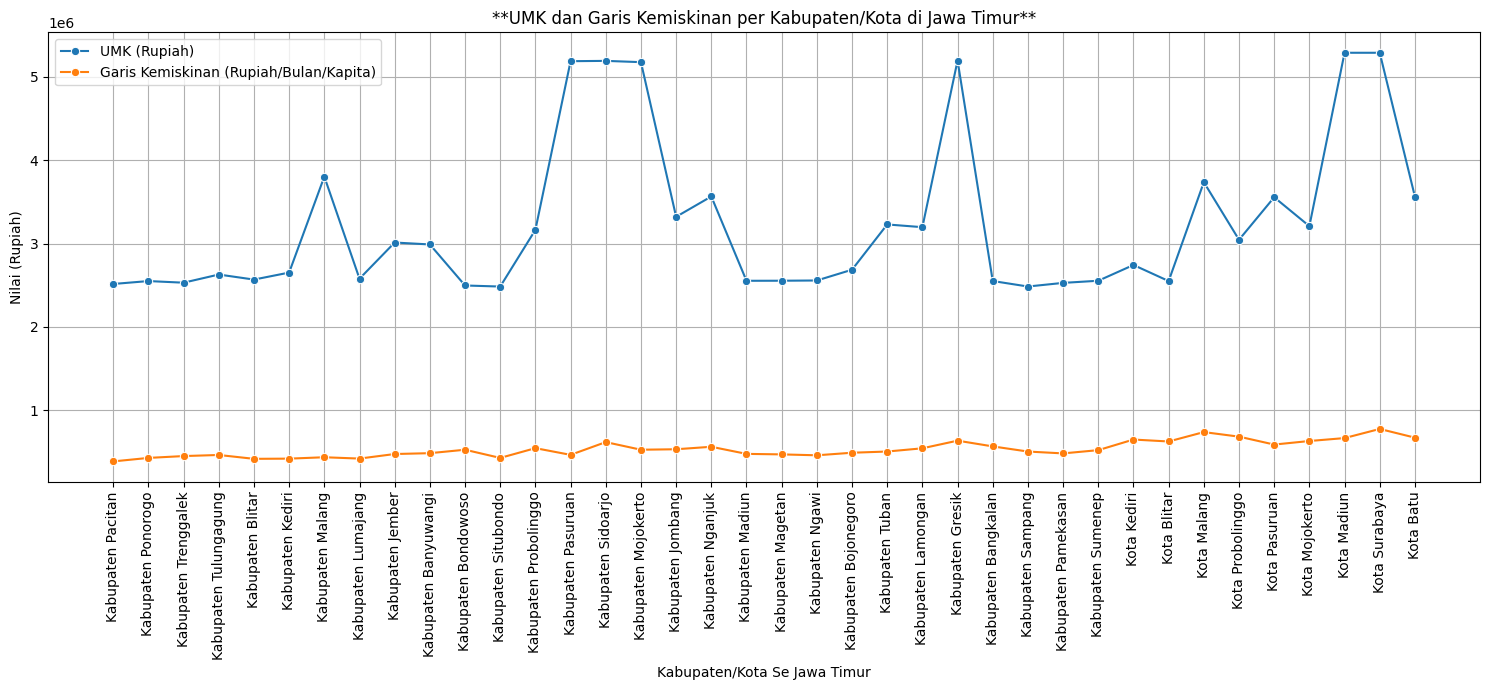

Korelasi: 0.5176156420427215


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [38]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='Kabupaten/Kota Se Jawa Timur', y='UMK (Rupiah)', label='UMK (Rupiah)', marker='o')
sns.lineplot(data=df, x='Kabupaten/Kota Se Jawa Timur', y='Garis Kemiskinan (Rupiah/Bulan/Kapita)', label='Garis Kemiskinan (Rupiah/Bulan/Kapita)', marker='o')
plt.title('**UMK dan Garis Kemiskinan per Kabupaten/Kota di Jawa Timur**')
plt.xlabel('Kabupaten/Kota Se Jawa Timur')
plt.ylabel('Nilai (Rupiah)')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

corr = df['UMK (Rupiah)'].corr(df['Garis Kemiskinan (Rupiah/Bulan/Kapita)'])
print("Korelasi:", corr)
print


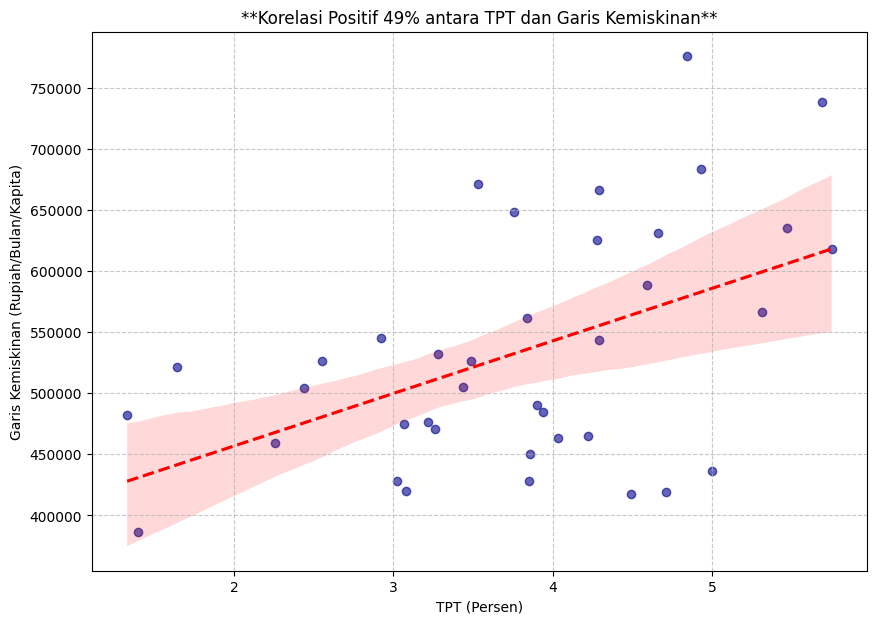

Koefisien Korelasi antara TPT dan Garis Kemiskinan: 0.49


In [39]:
# Pilih dua variabel yang diminati
var_x = 'TPT (Persen)'
var_y = 'Garis Kemiskinan (Rupiah/Bulan/Kapita)'

# Buat scatter plot dengan garis regresi
plt.figure(figsize=(10, 7))
sns.regplot(data=df, x=var_x, y=var_y, ci=95, scatter_kws={'color':'darkblue', 'alpha':0.6}, line_kws={'color':'red', 'linestyle':'--'})
plt.title(f'**Korelasi Positif 49% antara TPT dan Garis Kemiskinan**')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Hitung dan tampilkan koefisien korelasi
correlation = df[var_x].corr(df[var_y])
print(f"Koefisien Korelasi antara TPT dan Garis Kemiskinan: {correlation:.2f}")

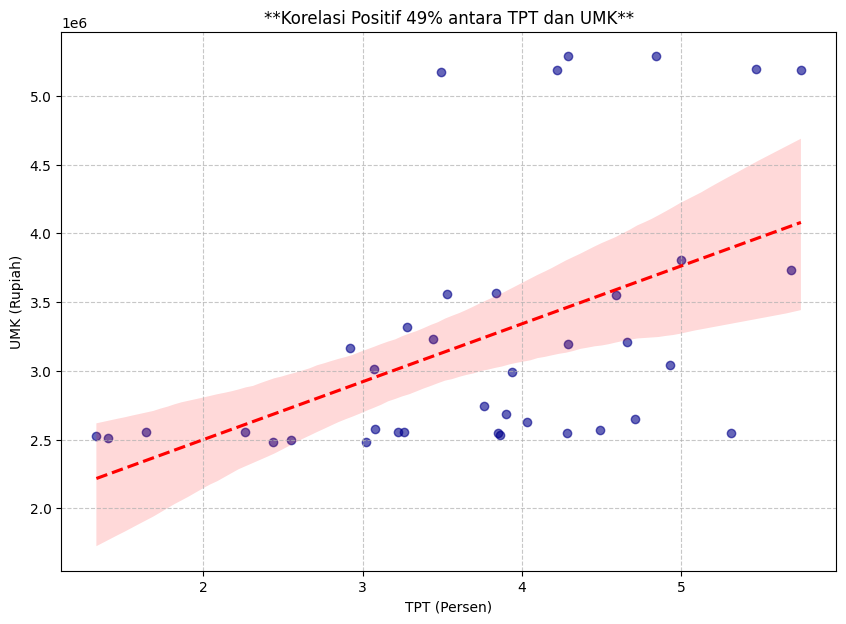

Koefisien Korelasi antara TPT dan UMK: 0.49


In [40]:
# Pilih dua variabel yang diminati
var_x = 'TPT (Persen)'
var_y = 'UMK (Rupiah)'

# Buat scatter plot dengan garis regresi
plt.figure(figsize=(10, 7))
sns.regplot(data=df, x=var_x, y=var_y, ci=95, scatter_kws={'color':'darkblue', 'alpha':0.6}, line_kws={'color':'red', 'linestyle':'--'})
plt.title(f'**Korelasi Positif 49% antara TPT dan UMK**')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Hitung dan tampilkan koefisien korelasi
correlation = df[var_x].corr(df[var_y])
print(f"Koefisien Korelasi antara TPT dan UMK: {correlation:.2f}")

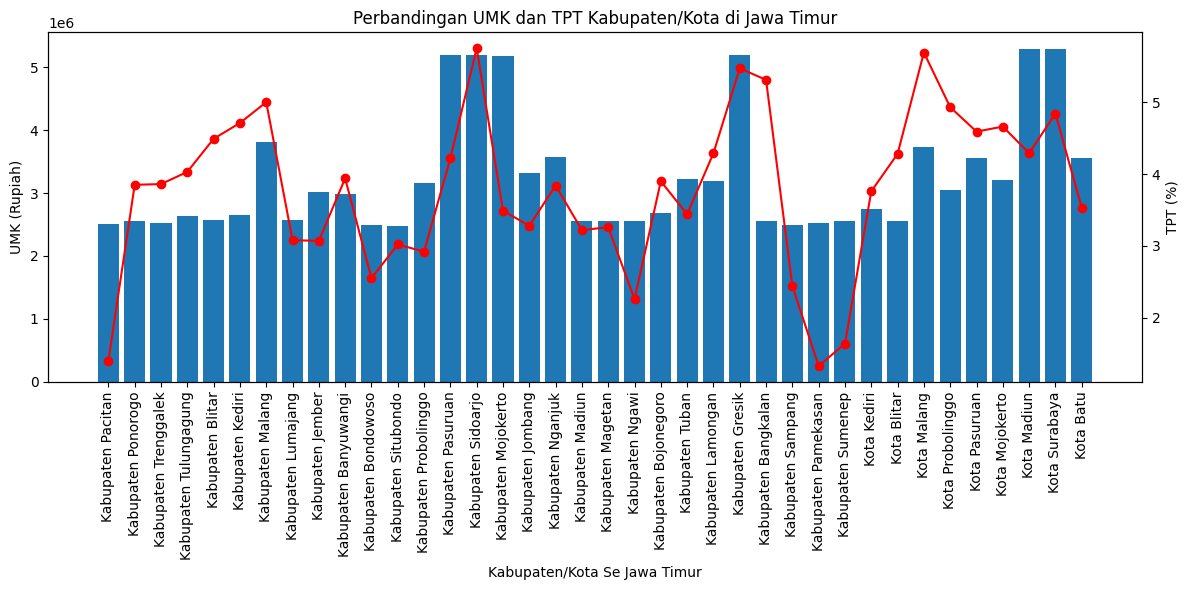

In [41]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart untuk UMK
ax1.bar(df["Kabupaten/Kota Se Jawa Timur"], df["UMK (Rupiah)"])
ax1.set_xlabel("Kabupaten/Kota Se Jawa Timur")
ax1.set_ylabel("UMK (Rupiah)")
ax1.tick_params(axis='x', rotation=90)

# Line chart untuk TPT
ax2 = ax1.twinx()
ax2.plot(df["Kabupaten/Kota Se Jawa Timur"], df["TPT (Persen)"], marker='o', color="red")
ax2.set_ylabel("TPT (%)")

plt.title("Perbandingan UMK dan TPT Kabupaten/Kota di Jawa Timur")

plt.tight_layout()
plt.show()

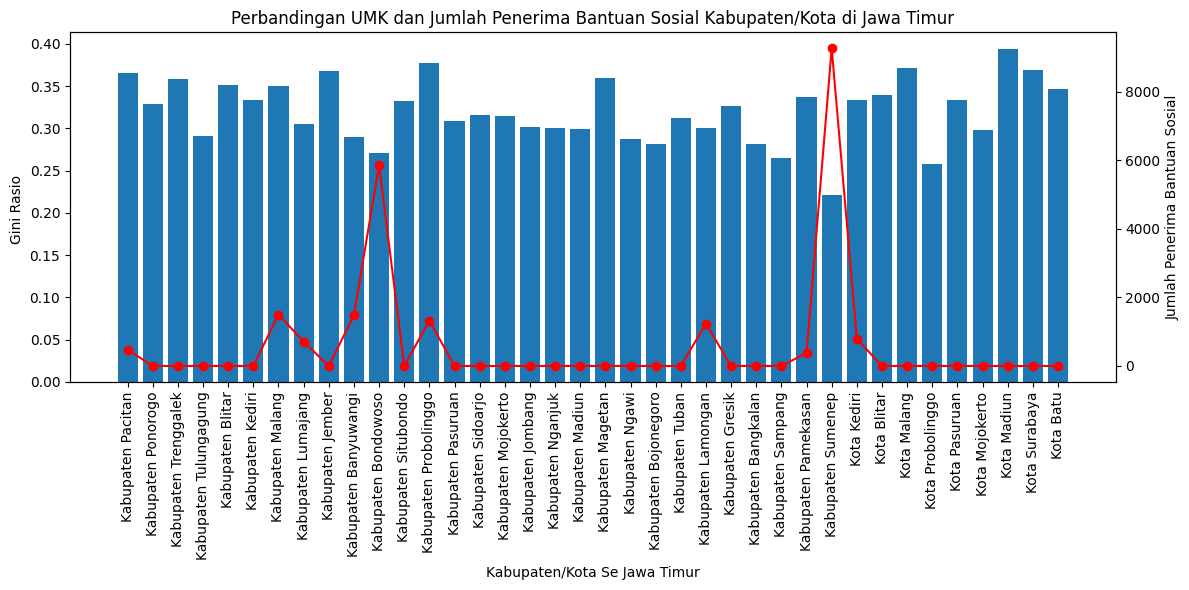

In [42]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart untuk UMK
ax1.bar(df["Kabupaten/Kota Se Jawa Timur"], df["Gini Rasio"])
ax1.set_xlabel("Kabupaten/Kota Se Jawa Timur")
ax1.set_ylabel("Gini Rasio ")
ax1.tick_params(axis='x', rotation=90)

# Line chart untuk TPT
ax2 = ax1.twinx()
ax2.plot(df["Kabupaten/Kota Se Jawa Timur"], df["Jumlah Penerima Bantuan Sosial"], marker='o', color="red")
ax2.set_ylabel("Jumlah Penerima Bantuan Sosial")

plt.title("Perbandingan UMK dan Jumlah Penerima Bantuan Sosial Kabupaten/Kota di Jawa Timur")

plt.tight_layout()
plt.show()

# MEMBANGUN DAN MENGEVAKUASI MODEL

## Model K-Means

In [43]:
#Pakai data yang sudah dinormalisasikan
X_cluster = df[cols].copy()

# Menerpakan MinMax hasil normlisasi pada data numerik
scaler = MinMaxScaler()
df_scaled_df = pd.DataFrame(scaler.fit_transform(X_cluster), columns=cols)

wcss = []
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled_df)
    wcss.append(kmeans.inertia_)

print("WCSS values calculated for K from 1 to 10.")
print(wcss)

WCSS values calculated for K from 1 to 10.
[16.093545705752604, 10.583678033672758, 8.037088298718789, 6.558536433305736, 5.744806335481174, 4.868213341949748, 4.368388374041518, 3.7884463972715325, 3.409030666858298, 3.06373121289248]


Klaster paling optimal bedasarkan identifikasi metode elbow adalah: 4


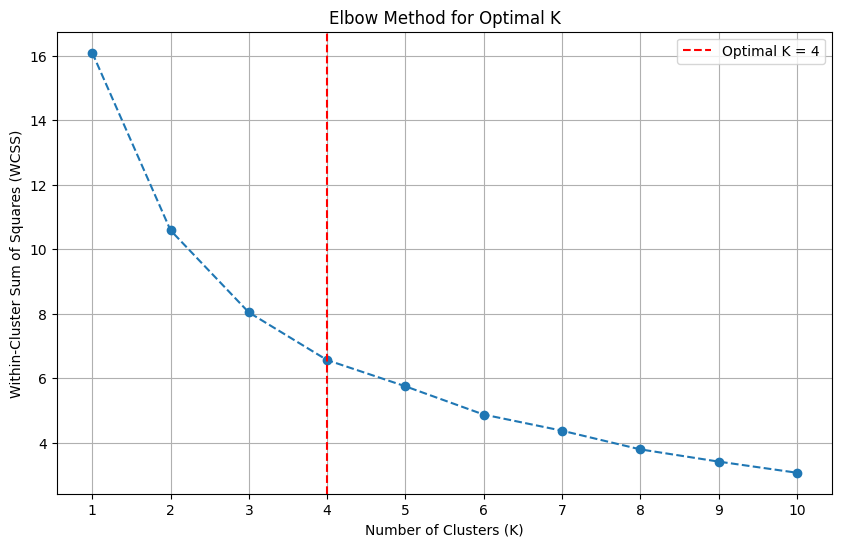

In [44]:
# Mengatur bingkai grafik
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)

# Mencari best K
kl = KneeLocator(range(1, max_k + 1), wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow

if optimal_k is not None:
    plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
    plt.legend()
    print(f"Klaster paling optimal bedasarkan identifikasi metode elbow adalah: {optimal_k}")
else:
    print("Tidak bisa menidentifikasi nilai k terbaik menggunakan metode elbow.")

plt.show()

K = 2, Silhouette Score = 0.3838
K = 3, Silhouette Score = 0.2709
K = 4, Silhouette Score = 0.2549
K = 5, Silhouette Score = 0.2505
K = 6, Silhouette Score = 0.2582
K = 7, Silhouette Score = 0.2504
K = 8, Silhouette Score = 0.2182
K = 9, Silhouette Score = 0.2284


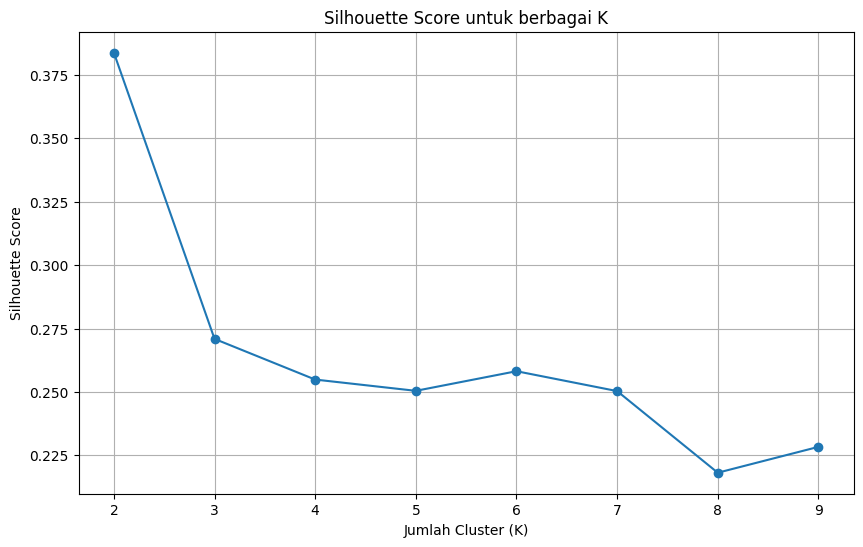

In [45]:
# Mencari Silhouette Score
range_k = range(2, 10)
scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init for KMeans
    labels = kmeans.fit_predict(df_scaled_df)
    score = silhouette_score(df_scaled_df, labels)
    scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range_k, scores, marker='o')
plt.title('Silhouette Score untuk berbagai K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


In [46]:
# Menerapkan Model K-Means
# Tentukan K sendiri

X_cluster = df_normalization[cols]

k = 3
kmeans_final = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

# Jalankan clustering
df_normalization['Cluster'] = kmeans_final.fit_predict(X_cluster)

# Masukkan cluster ke data asli
df['Cluster'] = df_normalization['Cluster']

print("Cluster distribution:")
print(df['Cluster'].value_counts())

print("\nData dengan cluster:")
print(df.head())

Cluster distribution:
Cluster
0    21
2    11
1     6
Name: count, dtype: int64

Data dengan cluster:
  Kabupaten/Kota Se Jawa Timur  Garis Kemiskinan (Rupiah/Bulan/Kapita)  \
0            Kabupaten Pacitan                                  386174   
1           Kabupaten Ponorogo                                  428183   
2         Kabupaten Trenggalek                                  450334   
3        Kabupaten Tulungagung                                  463364   
4             Kabupaten Blitar                                  417158   

   Jumlah Penerima Bantuan Sosial  UMK (Rupiah)  TPT (Persen)  \
0                             469       2514892          1.40   
1                               0       2549876          3.85   
2                               0       2530313          3.86   
3                               0       2628190          4.03   
4                               0       2567744          4.49   

   Indeks Kedalaman Kemiskinan (P1)  Indeks Keparahan Kemiskin

In [47]:
df.groupby('Cluster')[["Garis Kemiskinan (Rupiah/Bulan/Kapita)",
                      "UMK (Rupiah)",
                      "TPT (Persen)",
                      "Indeks Kedalaman Kemiskinan (P1)",
                      "Indeks Keparahan Kemiskinan (P2)",
                      "Gini Rasio",
                      "Rasio UMK & GK"]].mean()

,Garis Kemiskinan (Rupiah/Bulan/Kapita),UMK (Rupiah),TPT (Persen),Indeks Kedalaman Kemiskinan (P1),Indeks Keparahan Kemiskinan (P2),Gini Rasio,Rasio UMK & GK
Cluster,,,,,,,
0,529342.238095,2.991909e+06,4.055238,0.799524,0.144762,0.326429,5.764037
1,614332.166667,5.221386e+06,4.676667,0.936667,0.236667,0.338333,8.722248
2,496670.909091,2.665257e+06,2.764545,1.891818,0.380000,0.299727,5.402232


In [48]:
#Mengubah Nama Cluster
cluster_labels = {
    0 : 'Daerah dengan Tingkat Kemiskinan Rendah',
    1 : 'Daerah dengan Tingkat Kemiskinan Sedang',
    2 : 'Daerah dengan Tingkat Kemiskinan Tinggi',
}
# Map numerical clusters in df_normalization to descriptive labels
df['Cluster'] = df['Cluster'].map(cluster_labels)

In [49]:
print(df[['Kabupaten/Kota Se Jawa Timur', 'Cluster']].head(100))
print("\nDistribusi Cluster:")
print(df['Cluster'].value_counts())

   Kabupaten/Kota Se Jawa Timur                                  Cluster
0             Kabupaten Pacitan  Daerah dengan Tingkat Kemiskinan Tinggi
1            Kabupaten Ponorogo  Daerah dengan Tingkat Kemiskinan Rendah
2          Kabupaten Trenggalek  Daerah dengan Tingkat Kemiskinan Rendah
3         Kabupaten Tulungagung  Daerah dengan Tingkat Kemiskinan Rendah
4              Kabupaten Blitar  Daerah dengan Tingkat Kemiskinan Rendah
5              Kabupaten Kediri  Daerah dengan Tingkat Kemiskinan Rendah
6              Kabupaten Malang  Daerah dengan Tingkat Kemiskinan Rendah
7            Kabupaten Lumajang  Daerah dengan Tingkat Kemiskinan Rendah
8              Kabupaten Jember  Daerah dengan Tingkat Kemiskinan Rendah
9          Kabupaten Banyuwangi  Daerah dengan Tingkat Kemiskinan Rendah
10          Kabupaten Bondowoso  Daerah dengan Tingkat Kemiskinan Tinggi
11          Kabupaten Situbondo  Daerah dengan Tingkat Kemiskinan Rendah
12        Kabupaten Probolinggo  Daerah dengan Ting

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Kabupaten/Kota Se Jawa Timur            38 non-null     object 
 1   Garis Kemiskinan (Rupiah/Bulan/Kapita)  38 non-null     int64  
 2   Jumlah Penerima Bantuan Sosial          38 non-null     int64  
 3   UMK (Rupiah)                            38 non-null     int64  
 4   TPT (Persen)                            38 non-null     float64
 5   Indeks Kedalaman Kemiskinan (P1)        38 non-null     float64
 6   Indeks Keparahan Kemiskinan (P2)        38 non-null     float64
 7   Gini Rasio                              38 non-null     float64
 8   Rasio UMK & GK                          38 non-null     float64
 9   Kategori Kesejahteraan                  38 non-null     object 
 10  Cluster                                 38 non-null     object 


In [51]:
df.head(100)

,Kabupaten/Kota Se Jawa Timur,Garis Kemiskinan (Rupiah/Bulan/Kapita),Jumlah Penerima Bantuan Sosial,UMK (Rupiah),TPT (Persen),Indeks Kedalaman Kemiskinan (P1),Indeks Keparahan Kemiskinan (P2),Gini Rasio,Rasio UMK & GK,Kategori Kesejahteraan,Cluster
0,Kabupaten Pacitan,386174,469,2514892,1.40,1.77,0.36,0.365,6.512329,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Tinggi
1,Kabupaten Ponorogo,428183,0,2549876,3.85,1.22,0.26,0.329,5.955108,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
2,Kabupaten Trenggalek,450334,0,2530313,3.86,1.09,0.20,0.359,5.618747,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
3,Kabupaten Tulungagung,463364,0,2628190,4.03,0.42,0.04,0.291,5.671977,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
4,Kabupaten Blitar,417158,0,2567744,4.49,1.21,0.27,0.351,6.155327,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
5,Kabupaten Kediri,419486,0,2651603,4.71,1.00,0.19,0.334,6.321076,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
6,Kabupaten Malang,436153,1500,3802862,5.00,0.90,0.15,0.350,8.719101,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
7,Kabupaten Lumajang,420165,710,2578320,3.08,0.68,0.08,0.305,6.136446,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
8,Kabupaten Jember,474903,0,3012197,3.07,0.53,0.05,0.368,6.342763,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah
9,Kabupaten Banyuwangi,485012,1474,2989145,3.94,0.41,0.06,0.290,6.163033,Kelas Menengah,Daerah dengan Tingkat Kemiskinan Rendah


In [52]:
#df.to_csv("Hasil Final.csv", index=False)

In [53]:
# Input file GeoJSON
geojson_filename = "Kabupaten-Kota (Provinsi Jawa Timur).geojson"

gdf = gpd.read_file(geojson_filename)

print(f"File '{geojson_filename}' berhasil dibaca.")
print(gdf.head())

File 'Kabupaten-Kota (Provinsi Jawa Timur).geojson' berhasil dibaca.
  ID_0    COUNTRY      NAME_1 NL_NAME_1        ID_2      NAME_2 VARNAME_2  \
0  IDN  Indonesia  Jawa Timur      None  IDN.11.1_1   Bangkalan      None   
1  IDN  Indonesia  Jawa Timur      None  IDN.11.2_1  Banyuwangi      None   
2  IDN  Indonesia  Jawa Timur      None  IDN.11.3_1        Batu      None   
3  IDN  Indonesia  Jawa Timur      None  IDN.11.4_1      Blitar      None   
4  IDN  Indonesia  Jawa Timur      None  IDN.11.5_1  Bojonegoro      None   

  NL_NAME_2     TYPE_2 ENGTYPE_2  CC_2    HASC_2  \
0      None  Kabupaten   Regency  3526  ID.JI.BK   
1      None  Kabupaten   Regency  3510  ID.JI.BW   
2      None       Kota      City  3579  ID.JI.BA   
3      None  Kabupaten   Regency  3505  ID.JI.BR   
4      None  Kabupaten   Regency  3522  ID.JI.BJ   

                                            geometry  
0  MULTIPOLYGON (((112.97428 -7.1996, 112.97409 -...  
1  MULTIPOLYGON (((114.36061 -8.65745, 114.36

In [54]:
with open(geojson_filename) as f:
    geojson = json.load(f)

# Melihat nama kota/kabupaten di geojson
name_2_values = [feature['properties']['NAME_2'] for feature in geojson['features']]
print(sorted(list(set(name_2_values))))

['Bangkalan', 'Banyuwangi', 'Batu', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Gresik', 'Jember', 'Jombang', 'Kediri', 'Kota Blitar', 'Kota Kediri', 'Kota Madiun', 'Kota Malang', 'Kota Mojokerto', 'Kota Pasuruan', 'Kota Probolinggo', 'Lamongan', 'Lumajang', 'Madiun', 'Magetan', 'Malang', 'Mojokerto', 'Nganjuk', 'Ngawi', 'Pacitan', 'Pamekasan', 'Pasuruan', 'Ponorogo', 'Probolinggo', 'Sampang', 'Sidoarjo', 'Situbondo', 'Sumenep', 'Surabaya', 'Trenggalek', 'Tuban', 'Tulungagung']


In [55]:
def samakan_format(nama):
    nama = nama.strip().title()

    if "Kota" in nama:
        return nama
    else:
        nama = re.sub(r'Kabupaten ', '', nama)
        return nama

df["nama_fix"] = df["Kabupaten/Kota Se Jawa Timur"].apply(samakan_format)

In [56]:
print(sorted(df["nama_fix"].unique()))

['Bangkalan', 'Banyuwangi', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Gresik', 'Jember', 'Jombang', 'Kediri', 'Kota Batu', 'Kota Blitar', 'Kota Kediri', 'Kota Madiun', 'Kota Malang', 'Kota Mojokerto', 'Kota Pasuruan', 'Kota Probolinggo', 'Kota Surabaya', 'Lamongan', 'Lumajang', 'Madiun', 'Magetan', 'Malang', 'Mojokerto', 'Nganjuk', 'Ngawi', 'Pacitan', 'Pamekasan', 'Pasuruan', 'Ponorogo', 'Probolinggo', 'Sampang', 'Sidoarjo', 'Situbondo', 'Sumenep', 'Trenggalek', 'Tuban', 'Tulungagung']


In [57]:
jatim = gpd.read_file(geojson_filename)
jatim_merge = jatim.merge(
    df,
    left_on="NAME_2",
    right_on="nama_fix",
    how="left"
)

In [58]:
jatim_merge['Cluster'].isna().sum()

np.int64(2)

In [59]:
set(jatim["NAME_2"]) - set(df["nama_fix"])

{'Batu', 'Surabaya'}

In [60]:
def samakan_format(nama):
    nama = nama.strip().title()

    if nama == "Kota Batu":
        return "Batu"
    if nama == "Kota Surabaya":
        return "Surabaya"

    if "Kota" in nama:
        return nama
    else:
        return nama.replace("Kabupaten ", "")

df["nama_fix"] = df["Kabupaten/Kota Se Jawa Timur"].apply(samakan_format)

In [61]:
set(jatim["NAME_2"]) - set(df["nama_fix"])

set()

In [62]:
jatim = gpd.read_file(geojson_filename)
jatim_merge = jatim.merge(
    df,
    left_on="NAME_2",
    right_on="nama_fix",
    how="left"
)

In [63]:
jatim_merge["Cluster"].isna().sum()

np.int64(0)

In [64]:
# Ambil kolom yang diperlukan
df_kab_kota_cluster = df[['Kabupaten/Kota Se Jawa Timur', 'Cluster']].copy()

# Hapus kata "Kabupaten "
df_kab_kota_cluster['Kabupaten/Kota Se Jawa Timur'] = (
    df_kab_kota_cluster['Kabupaten/Kota Se Jawa Timur']
    .str.replace('Kabupaten ', '', regex=False)
)

# Khusus Surabaya dan Batu hapus kata "Kota"
df_kab_kota_cluster['Kabupaten/Kota Se Jawa Timur'] = (
    df_kab_kota_cluster['Kabupaten/Kota Se Jawa Timur']
    .str.replace('Kota Surabaya', 'Surabaya', regex=False)
    .str.replace('Kota Batu', 'Batu', regex=False)
)

print(df_kab_kota_cluster.head())

# Simpan ke CSV
df_kab_kota_cluster.to_csv('kabupaten_kota_cluster.csv', index=False)

print("File kabupaten_kota_cluster.csv berhasil dibuat")

  Kabupaten/Kota Se Jawa Timur                                  Cluster
0                      Pacitan  Daerah dengan Tingkat Kemiskinan Tinggi
1                     Ponorogo  Daerah dengan Tingkat Kemiskinan Rendah
2                   Trenggalek  Daerah dengan Tingkat Kemiskinan Rendah
3                  Tulungagung  Daerah dengan Tingkat Kemiskinan Rendah
4                       Blitar  Daerah dengan Tingkat Kemiskinan Rendah
File kabupaten_kota_cluster.csv berhasil dibuat


In [65]:
# Baca dataset cluster
df = pd.read_csv("kabupaten_kota_cluster.csv")

# Baca file geojson Jawa Timur
with open("Kabupaten-Kota (Provinsi Jawa Timur).geojson") as f:
    geojson = json.load(f)

# Buat peta choropleth
fig = px.choropleth(
    df,
    geojson=geojson,
    locations="Kabupaten/Kota Se Jawa Timur", # Corrected column name
    featureidkey="properties.NAME_2", # biasanya nama kab/kota di geojson
    color="Cluster",

    # warna mengikuti cluster
    color_discrete_map={
        'Daerah dengan Tingkat Kemiskinan Tinggi': "red",
        'Daerah dengan Tingkat Kemiskinan Sedang': "orange",
        'Daerah dengan Tingkat Kemiskinan Rendah': "green"
    },

    hover_name="Kabupaten/Kota Se Jawa Timur" # Corrected column name
)

# Menyesuaikan tampilan peta
fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    title="Peta Cluster Kemiskinan Kabupaten/Kota di Jawa Timur",
    title_x=0.5,
    width=900,
    height=900
)
pio.renderers.default = "browser"
fig.show()

## Model K-NN

In [66]:
# Reload the original dataset for KNN to get unnormalized features

X = df_normalization[cols]
y = df['Cluster']

# Ubah data latih 80 dan data uji 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (30, 7)
Shape of X_test: (8, 7)
Shape of y_train: (30,)
Shape of y_test: (8,)


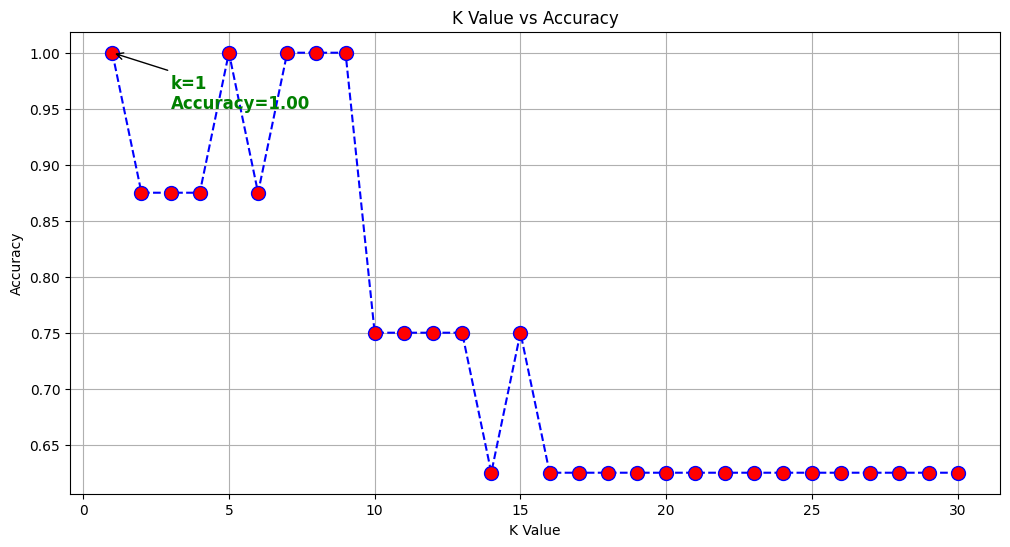

Nilai k terbaik: 1 dengan Accuracy: 1.00


In [67]:
error = []
max_k = len(X_train)

# Loop untuk mencari nilai k terbaik untuk KNN
for i in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors=i)  # Menentukan nilai k
    knn.fit(X_train, y_train)  # Melatih model dengan data training
    pred_i = knn.predict(X_test)  # Melakukan prediksi pada data test
    accuracy = accuracy_score(y_test, pred_i)  # Menghitung akurasi
    error.append(accuracy)  # Menyimpan hasil akurasi dalam list

# Menampilkan hasil error (akurasinya)
best_k = np.argmax(error) + 1  # Menambahkan 1 karena index dimulai dari 0
best_accuracy = error[best_k - 1]

# Menampilkan grafik
plt.figure(figsize=(12, 6))
plt.plot(range(1, max_k + 1), error, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('K Value vs Accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

# Menambahkan teks untuk nilai k terbaik dan akurasi
plt.annotate(f'k={best_k}\nAccuracy={best_accuracy:.2f}',
             xy=(best_k, best_accuracy),
             xytext=(best_k + 2, best_accuracy - 0.05),  # Posisi teks
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=12, color='green', fontweight='bold')

# Menampilkan grafik
plt.grid(True)
plt.show()

# Menampilkan nilai k terbaik
print(f'Nilai k terbaik: {best_k} dengan Accuracy: {best_accuracy:.2f}')

In [68]:
# Menerapkan model algoritma KNN dengan K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Hasil prediksi
y_pred = knn.predict(X_test)

# Evaluaasi model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nKNN Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

# Cek prediksi data uji
predictions_df = pd.DataFrame({'Actual_Cluster': y_test, 'Predicted_Cluster': y_pred})
print("\nSample Predictions:")
print(predictions_df.head(100))


KNN Model Accuracy: 1.00

Classification Report:
                                         precision    recall  f1-score   support

Daerah dengan Tingkat Kemiskinan Rendah       1.00      1.00      1.00         5
Daerah dengan Tingkat Kemiskinan Sedang       1.00      1.00      1.00         1
Daerah dengan Tingkat Kemiskinan Tinggi       1.00      1.00      1.00         2

                               accuracy                           1.00         8
                              macro avg       1.00      1.00      1.00         8
                           weighted avg       1.00      1.00      1.00         8


Sample Predictions:
                             Actual_Cluster  \
7   Daerah dengan Tingkat Kemiskinan Rendah   
27  Daerah dengan Tingkat Kemiskinan Tinggi   
16  Daerah dengan Tingkat Kemiskinan Rendah   
34  Daerah dengan Tingkat Kemiskinan Rendah   
8   Daerah dengan Tingkat Kemiskinan Rendah   
14  Daerah dengan Tingkat Kemiskinan Sedang   
29  Daerah dengan Tingkat Kemi

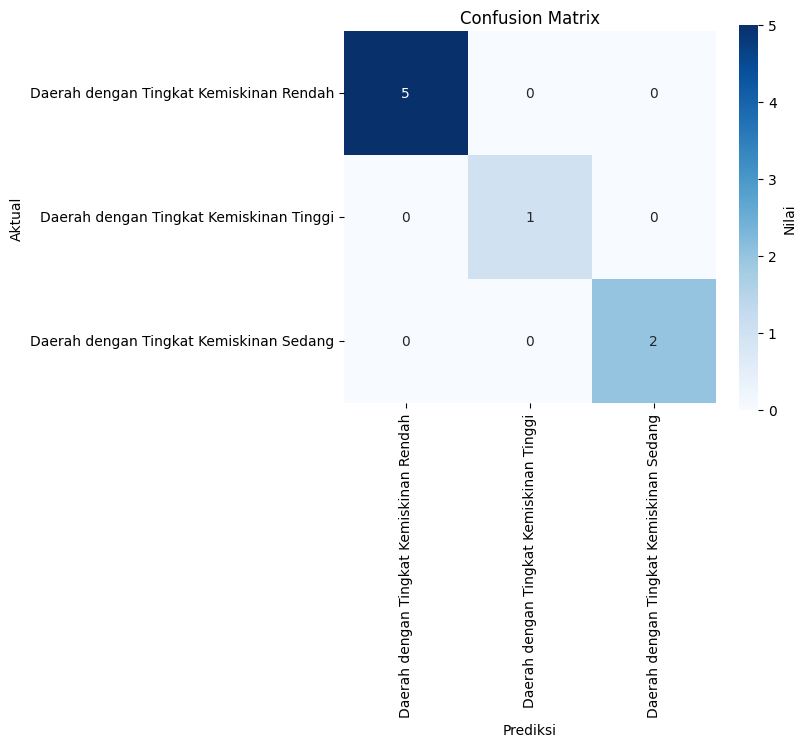

In [69]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            xticklabels=y_test.unique(), yticklabels=y_test.unique())

# Menambahkan keterangan di sumbu X dan Y
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')

# Mendapatkan colorbar yang sudah ada dari heatmap
cbar = plt.gca().collections[0].colorbar
cbar.set_label('Nilai')  # Menambahkan label pada colorbar

plt.show()

# Input Data Baru

## Daerah dengan Tingkat Kemiskinan Rendah

In [70]:
# Input data dari user
garis_kemiskinan = float(input("Masukkan Garis Kemiskinan (Rupiah/Bulan/Kapita), c/550000  : "))
umk = float(input("Masukkan UMK (Rupiah), c/2500000 : "))
tpt = float(input("Masukkan TPT (Persen), c/4.5: "))
p1 = float(input("Masukkan Indeks Kedalaman Kemiskinan (P1), c/0.7 : "))
p2 = float(input("Masukkan Indeks Keparahan Kemiskinan (P2), c/1.2 : "))
gini_rasio = float(input("Masukkan Gini Rasio, c/0.324 : "))
rasio_umk_gk = float(input("Masukkan Rasio UMK & Garis Kemiskinan c/2: "))

# Menggabungkan semua input menjadi satu data
data_baru = [[
    garis_kemiskinan,
    umk,
    tpt,
    p1,
    p2,
    gini_rasio,
    rasio_umk_gk
]]

print("\nData yang dimasukkan:")
print(data_baru)


Data yang dimasukkan:
[[420000.0, 2600000.0, 2.0, 0.26, 0.08, 0.3, 6.0]]


In [71]:
#normalisasi
data_baru_scaled = scaler.transform(data_baru)
print()

print("Data baru yang sudah dinormalisasi:")
print(data_baru_scaled)
print()

cluster_pred = knn.predict(data_baru_scaled)
distances, indices = knn.kneighbors(data_baru_scaled)

print("Tetangga terdekat:")
print(y_train.iloc[indices[0]])
print()

print("Cluster hasil prediksi:", cluster_pred)



Data baru yang sudah dinormalisasi:
[[ 0.08686184  0.04137072  0.15158371 -0.03597122  0.05633803  0.4566474
   0.27144694]]

Tetangga terdekat:
11    Daerah dengan Tingkat Kemiskinan Rendah
3     Daerah dengan Tingkat Kemiskinan Rendah
9     Daerah dengan Tingkat Kemiskinan Rendah
19    Daerah dengan Tingkat Kemiskinan Rendah
20    Daerah dengan Tingkat Kemiskinan Tinggi
Name: Cluster, dtype: object

Cluster hasil prediksi: ['Daerah dengan Tingkat Kemiskinan Rendah']


c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Daerah dengan Tingkat Kemiskinan Sedang

In [72]:
# Input data dari user
garis_kemiskinan = float(input("Masukkan Garis Kemiskinan (Rupiah/Bulan/Kapita), c/550000  : "))
umk = float(input("Masukkan UMK (Rupiah), c/2500000 : "))
tpt = float(input("Masukkan TPT (Persen), c/4.5: "))
p1 = float(input("Masukkan Indeks Kedalaman Kemiskinan (P1), c/0.7 : "))
p2 = float(input("Masukkan Indeks Keparahan Kemiskinan (P2), c/1.2 : "))
gini_rasio = float(input("Masukkan Gini Rasio, c/0.324 : "))
rasio_umk_gk = float(input("Masukkan Rasio UMK & Garis Kemiskinan c/2: "))

# Menggabungkan semua input menjadi satu data
data_baru_3 = [[
    garis_kemiskinan,
    umk,
    tpt,
    p1,
    p2,
    gini_rasio,
    rasio_umk_gk
]]

print("\nData yang dimasukkan:")
print(data_baru_3)


Data yang dimasukkan:
[[630000.0, 5910000.0, 3.0, 1.92, 0.57, 0.327, 8.0]]


In [73]:
# normalisasi
data_baru_scaled = scaler.transform(data_baru_3)
print()

print("Data baru yang sudah dinormalisasi:")
print(data_baru_scaled)
print()

cluster_pred = knn.predict(data_baru_scaled)
distances, indices = knn.kneighbors(data_baru_scaled)

print("Tetangga terdekat:")
print(y_train.iloc[indices[0]])
print()

print("Cluster hasil prediksi:", cluster_pred)


Data baru yang sudah dinormalisasi:
[[0.62612121 1.22147621 0.37782805 0.56115108 0.74647887 0.61271676
  0.5538516 ]]

Tetangga terdekat:
15    Daerah dengan Tingkat Kemiskinan Sedang
24    Daerah dengan Tingkat Kemiskinan Sedang
17    Daerah dengan Tingkat Kemiskinan Rendah
13    Daerah dengan Tingkat Kemiskinan Sedang
22    Daerah dengan Tingkat Kemiskinan Tinggi
Name: Cluster, dtype: object

Cluster hasil prediksi: ['Daerah dengan Tingkat Kemiskinan Sedang']


c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Daerah dengan Tingkat Kemiskinan Tinggi

In [74]:
# Input data dari user
garis_kemiskinan = float(input("Masukkan Garis Kemiskinan (Rupiah/Bulan/Kapita), c/550000  : "))
umk = float(input("Masukkan UMK (Rupiah), c/2500000 : "))
tpt = float(input("Masukkan TPT (Persen), c/4.5: "))
p1 = float(input("Masukkan Indeks Kedalaman Kemiskinan (P1), c/0.7 : "))
p2 = float(input("Masukkan Indeks Keparahan Kemiskinan (P2), c/1.2 : "))
gini_rasio = float(input("Masukkan Gini Rasio, c/0.324 : "))
rasio_umk_gk = float(input("Masukkan Rasio UMK & Garis Kemiskinan c/2: "))

# Menggabungkan semua input menjadi satu data
data_baru_2 = [[
    garis_kemiskinan,
    umk,
    tpt,
    p1,
    p2,
    gini_rasio,
    rasio_umk_gk
]]

print("\nData yang dimasukkan:")
print(data_baru_2)


Data yang dimasukkan:
[[500000.0, 3500000.0, 3.5, 0.78, 1.2, 0.312, 7.0]]


In [75]:
# normalisasi
data_baru_scaled = scaler.transform(data_baru_2)
print()

print("Data baru yang sudah dinormalisasi:")
print(data_baru_scaled)
print()

cluster_pred = knn.predict(data_baru_scaled)
distances, indices = knn.kneighbors(data_baru_scaled)

print("Tetangga terdekat:")
print(y_train.iloc[indices[0]])
print()

print("Cluster hasil prediksi:", cluster_pred)


Data baru yang sudah dinormalisasi:
[[0.29229398 0.36224532 0.49095023 0.15107914 1.63380282 0.52601156
  0.41264927]]

Tetangga terdekat:
22    Daerah dengan Tingkat Kemiskinan Tinggi
25    Daerah dengan Tingkat Kemiskinan Tinggi
17    Daerah dengan Tingkat Kemiskinan Rendah
12    Daerah dengan Tingkat Kemiskinan Tinggi
24    Daerah dengan Tingkat Kemiskinan Sedang
Name: Cluster, dtype: object

Cluster hasil prediksi: ['Daerah dengan Tingkat Kemiskinan Tinggi']


c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanya Tania\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [76]:
# Simpan nama fitur
features_used = X_train.columns.tolist()

# Gabungkan semua dalam satu object
model_data = {
    'model': knn,
    'scaler': scaler,
    'features': features_used
}

# Simpan ke file
joblib.dump(model_data, 'KNN_Model.joblib')

print("Model KNN berhasil disimpan!")

Model KNN berhasil disimpan!
